<a href="https://colab.research.google.com/github/devdatta1429/nexthome/blob/main/DATA_ANALYSIS/hotel_booking_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


<p style="font-family: 'Segoe UI'; font-size: 20px; line-height: 1.6; color: #76fffa;">
    In the past few years, both the City Hotel and Resort Hotel have experienced significant increases in their cancellation rates. As a result, both hotels are currently facing a range of challenges, such as reduced revenue and underutilized hotel rooms. Therefore, the top priority for both hotels is to reduce their cancellation rates, which will enhance their efficiency in generating revenue. This report focuses on the analysis of hotel booking cancellations and other factors that do not directly impact their business and annual revenue generation.
</p>


**This database is taken from the following article:**
    
**Hotel Booking Demand Datasets, written by Nuno Antonio, Ana Almeida, and Luis Nunes for Data in Brief, Volume 22, February 2019.**

**Imports**

In [75]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

import os
os.chdir('/content/drive/MyDrive/CDAC/')

In [76]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


**1-Reading dataset**

In [78]:
df=pd.read_csv('hotel_booking.csv')

**2-Check basic database information.**

In [79]:
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,name,email,phone-number,credit_card
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,3,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01,Ernest Barnes,Ernest.Barnes31@outlook.com,669-792-1661,************4322
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,4,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01,Andrea Baker,Andrea_Baker94@aol.com,858-637-6955,************9157
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Direct,Direct,0,0,0,A,C,0,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02,Rebecca Parker,Rebecca_Parker@comcast.net,652-885-2745,************3734
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Corporate,Corporate,0,0,0,A,A,0,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02,Laura Murray,Laura_M@gmail.com,364-656-8427,************5677
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,0.0,0,BB,GBR,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03,Linda Hines,LHines@verizon.com,713-226-5883,************5498


In [80]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 36 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal            

In [81]:
df.shape

(119390, 36)

**3-How many rows does this dataframe have?**

In [82]:
print("Our dataset have ", df.shape[0] ,' rows.')

Our dataset have  119390  rows.


**4-Do we have lost data? If yes, which column has the most missing data?**

In [83]:
count_null=df.isnull().sum()
for i in range(df.shape[0]-2):
    if(count_null[i]>0):
        print('yes, we have at least one missing data.')
        break

yes, we have at least one missing data.


In [84]:
max_null_val=df.isnull().sum().idxmax()
print('The maximum number of Null data is in column *** ',max_null_val,' ***')

The maximum number of Null data is in column ***  company  ***


**5-Remove the company column from the dataframe.**

In [85]:
df=df.drop(['company'], axis = 1)

In [86]:
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,name,email,phone-number,credit_card
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,3,No Deposit,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01,Ernest Barnes,Ernest.Barnes31@outlook.com,669-792-1661,************4322
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,4,No Deposit,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01,Andrea Baker,Andrea_Baker94@aol.com,858-637-6955,************9157
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Direct,Direct,0,0,0,A,C,0,No Deposit,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02,Rebecca Parker,Rebecca_Parker@comcast.net,652-885-2745,************3734
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Corporate,Corporate,0,0,0,A,A,0,No Deposit,304.0,0,Transient,75.0,0,0,Check-Out,2015-07-02,Laura Murray,Laura_M@gmail.com,364-656-8427,************5677
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,0.0,0,BB,GBR,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,240.0,0,Transient,98.0,0,1,Check-Out,2015-07-03,Linda Hines,LHines@verizon.com,713-226-5883,************5498


**6-Which country do most travelers come from?**

**List the 5 countries with the most passengers.**

In [87]:
count_country=df.groupby(by='country')['name'].count()
count_country=count_country.sort_values(ascending=False)
df_count_country=pd.DataFrame(count_country)

print("The most travelers come from:\n ",count_country[:1])

print("\nList the 5 countries with the most passengers.\n",count_country[:5])

The most travelers come from:
  country
PRT    48590
Name: name, dtype: int64

List the 5 countries with the most passengers.
 country
PRT    48590
GBR    12129
FRA    10415
ESP     8568
DEU     7287
Name: name, dtype: int64


**7-Who has the most ADR? How much?**

In [88]:
ADR=df.groupby(by='name')['adr'].max()
ADR=ADR.sort_values(ascending=False)
ADR_df = pd.DataFrame(ADR)
print('The most ADR(Average Daily Rate) is:\n',ADR_df.iloc[0])

The most ADR(Average Daily Rate) is:
 adr    5400.0
Name: Daniel Walter, dtype: float64


**8-Specify the mean of the total ADR?** (two decimal places)

In [89]:
num_adr=df['adr'].count()
Avg_adr=df['adr'].sum()/num_adr

print('Average of total Average Daily Rate is:', Avg_adr.round(decimals=2))


Average of total Average Daily Rate is: 101.83


**9-Specify the average number of nights spent.** (two decimal places)

In [90]:
df['all_night']= df.apply(lambda x: x['stays_in_weekend_nights'] + x['stays_in_week_nights'], axis=1)
m = df['all_night'].mean()
np.round(m,2)

np.float64(3.43)

**10-Specify the Name and Email of people who had 5 special requests.**

In [91]:
df_day=df.groupby(by='phone-number')[['total_of_special_requests','name','email']].first()


for i in range(81503):
    if df_day.iloc[i][0] == 5:
        print(df_day.iloc[i],"\n\n")

total_of_special_requests                    5
name                               Sarah Floyd
email                        Sarah_F@gmail.com
Name: 100-586-7149, dtype: object 


total_of_special_requests                            5
name                                     Laura Sanders
email                        Sanders_Laura@hotmail.com
Name: 120-754-3942, dtype: object 


total_of_special_requests                         5
name                                 Melinda Jensen
email                        MelindaJensen@zoho.com
Name: 129-892-8585, dtype: object 


total_of_special_requests                     5
name                             Angela Hawkins
email                        Angela_H@gmail.com
Name: 198-157-4544, dtype: object 


total_of_special_requests                              5
name                                     Cynthia Cabrera
email                        Cabrera.Cynthia@xfinity.com
Name: 280-973-9357, dtype: object 


total_of_special_requests             

**11-What are the most common last name?**

In [92]:
df['last_name'] = df['name'].apply(lambda x : x[x.index(' ') + 1:])
df['last_name'].value_counts()[:5]

,count
last_name,
Smith,2466
Johnson,1968
Williams,1590
Jones,1420
Brown,1403


**12-Who has booked the hotel with the most children and babies?**

In [93]:
max_babies=df['babies'].idxmax()
max_children=df[ 'children'].idxmax()

print(df.iloc[max_children]["name"],
      " has booked a hotel with the largest number of children.")

print(df.iloc[max_babies]["name"],
      " has booked a hotel with the largest number of babies.")


Jamie Ramirez  has booked a hotel with the largest number of children.
Nicholas Parker  has booked a hotel with the largest number of babies.


**13-Specify the phone code of the areas that have the most hotel reservations.** (3 first codes)

In [94]:
phone_code=df['phone-number'].apply(lambda x : x[:3]).value_counts()[:3]

print("3 first codes that have the most hotel reservations :\n", phone_code)

3 first codes that have the most hotel reservations :
 phone-number
799    168
185    167
541    166
Name: count, dtype: int64


**Finished**

In [95]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# ==========================================
# 0. SETUP AND DATA PREPARATION
# ==========================================
# Load the dataset
df = pd.read_csv('hotel_booking.csv')

# Clean Data: Remove extreme ADR outliers and handle basic nulls
df_clean = df[df['adr'] < 1000].copy()
df_clean['country'] = df_clean['country'].fillna('Unknown')

# Create a total stay duration column
df_clean['total_stay'] = df_clean['stays_in_weekend_nights'] + df_clean['stays_in_week_nights']

# Set aesthetic theme
sns.set_theme(style="whitegrid", palette="muted")



```
# ==========================================
# SECTION 1: OVERVIEW & VOLUME (Vis 1-5)
# ==========================================

```

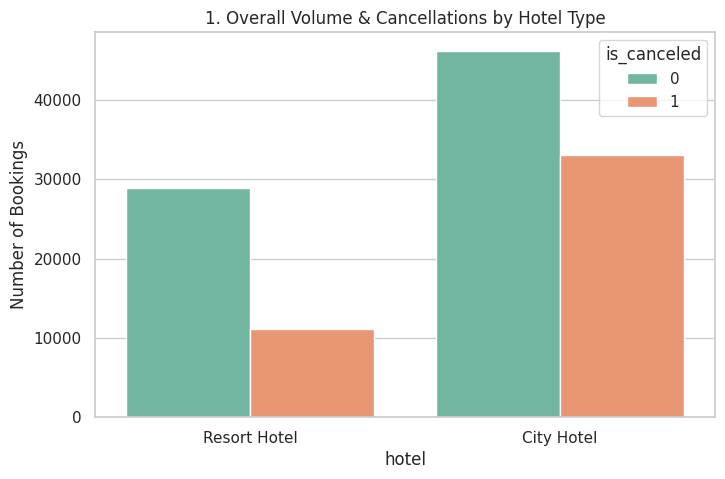

In [96]:
# 1. Total Bookings & Cancellations by Hotel
plt.figure(figsize=(8, 5))
sns.countplot(x='hotel', hue='is_canceled', data=df_clean, palette='Set2')
plt.title('1. Overall Volume & Cancellations by Hotel Type')
plt.ylabel('Number of Bookings')
plt.show()


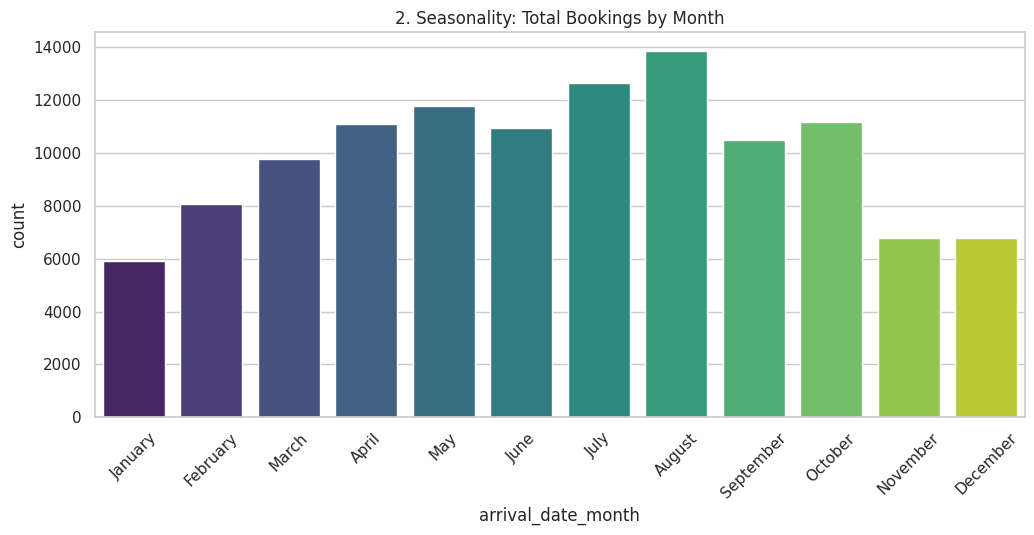

In [97]:

# 2. Monthly Booking Volume
months_order = ['January', 'February', 'March', 'April', 'May', 'June',
                'July', 'August', 'September', 'October', 'November', 'December']
plt.figure(figsize=(12, 5))
sns.countplot(x='arrival_date_month', data=df_clean, order=months_order, palette='viridis')
plt.title('2. Seasonality: Total Bookings by Month')
plt.xticks(rotation=45)
plt.show()


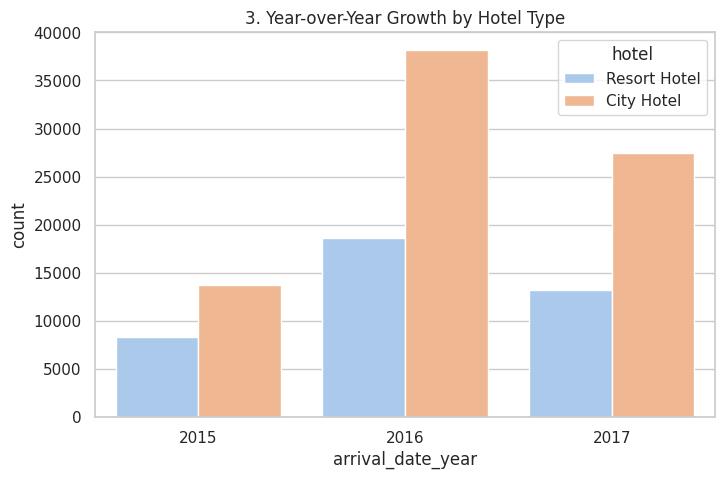

In [98]:

# 3. Bookings by Year
plt.figure(figsize=(8, 5))
sns.countplot(x='arrival_date_year', hue='hotel', data=df_clean, palette='pastel')
plt.title('3. Year-over-Year Growth by Hotel Type')
plt.show()


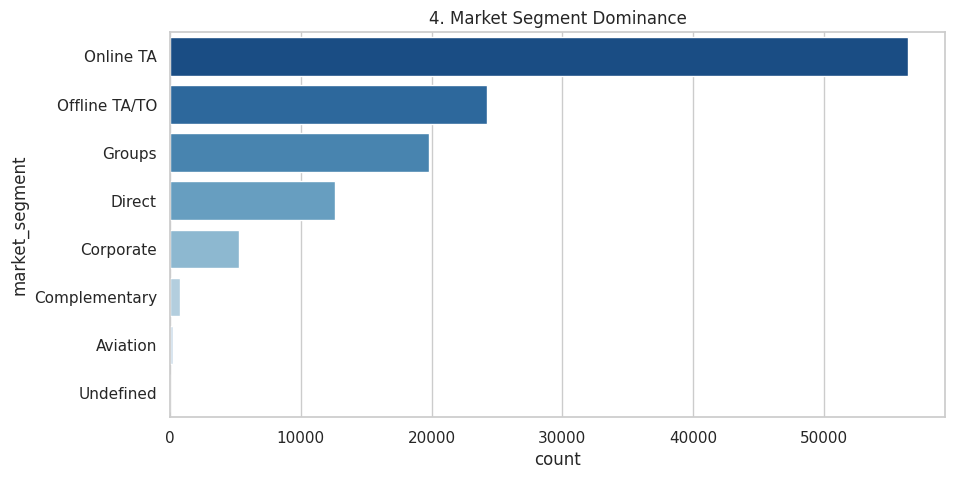

In [99]:

# 4. Market Segment Distribution
plt.figure(figsize=(10, 5))
sns.countplot(y='market_segment', data=df_clean, order=df_clean['market_segment'].value_counts().index, palette='Blues_r')
plt.title('4. Market Segment Dominance')
plt.show()


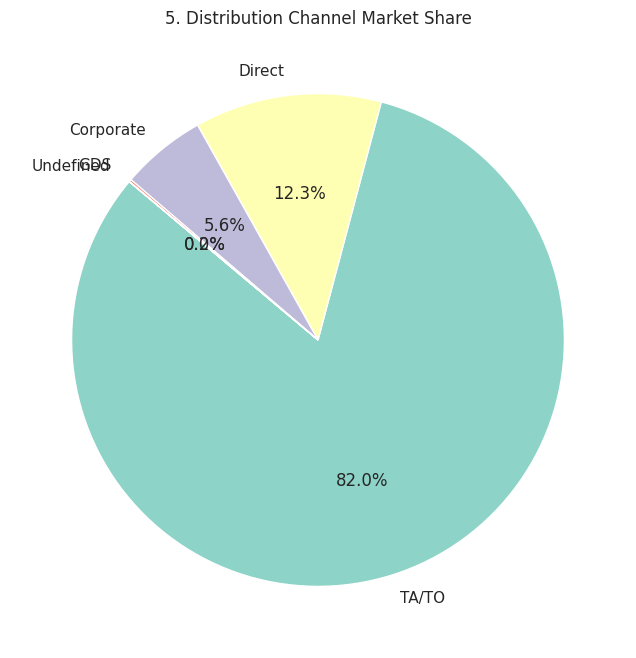

In [100]:

# 5. Distribution Channel Share
plt.figure(figsize=(8, 8))
channel_counts = df_clean['distribution_channel'].value_counts()
plt.pie(channel_counts, labels=channel_counts.index, autopct='%1.1f%%', startangle=140, colors=sns.color_palette("Set3"))
plt.title('5. Distribution Channel Market Share')
plt.show()


```
# ==========================================
# SECTION 2: PRICING & REVENUE (ADR) (Vis 6-10)
# ==========================================
```

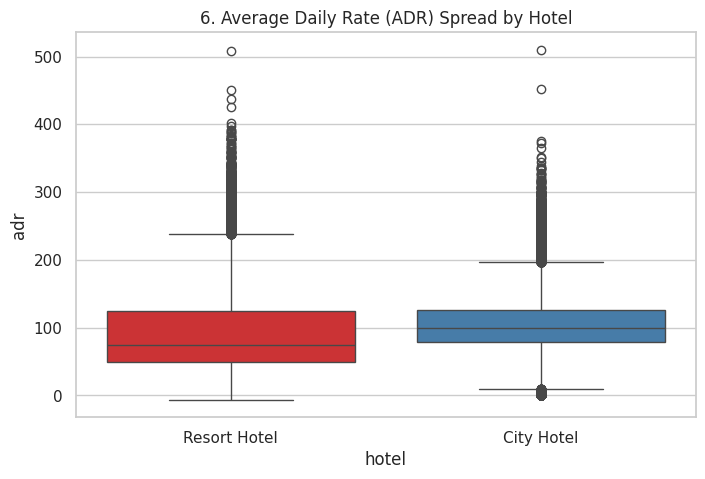

In [101]:

# 6. ADR Distribution by Hotel
plt.figure(figsize=(8, 5))
sns.boxplot(x='hotel', y='adr', data=df_clean, palette='Set1')
plt.title('6. Average Daily Rate (ADR) Spread by Hotel')
plt.show()


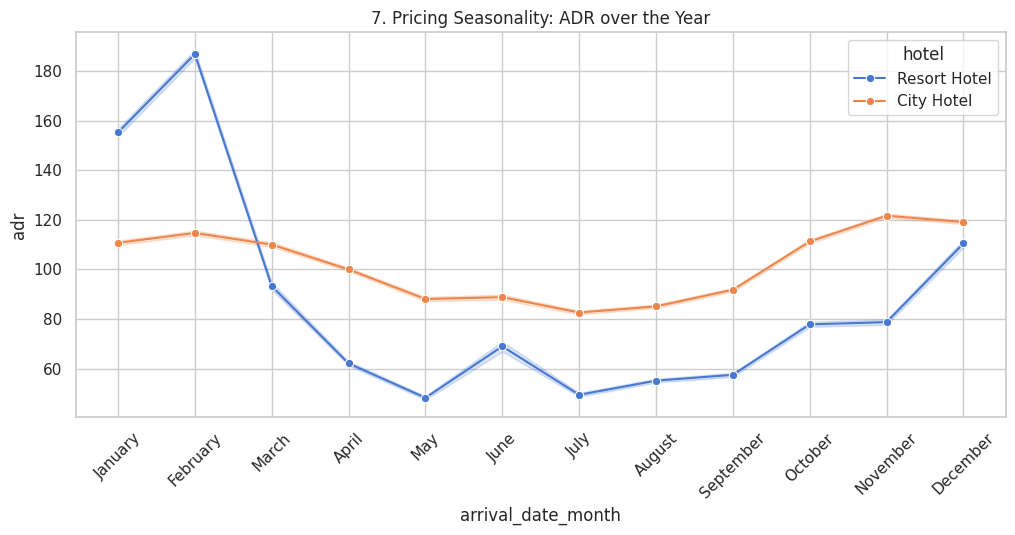

In [102]:

# 7. Monthly ADR Trends (Pricing Seasonality)
plt.figure(figsize=(12, 5))
sns.lineplot(x='arrival_date_month', y='adr', hue='hotel', data=df_clean, sort=False, estimator='mean', marker='o')
# Reordering the x-axis to match calendar months
plt.xticks(ticks=range(12), labels=months_order, rotation=45)
plt.title('7. Pricing Seasonality: ADR over the Year')
plt.show()


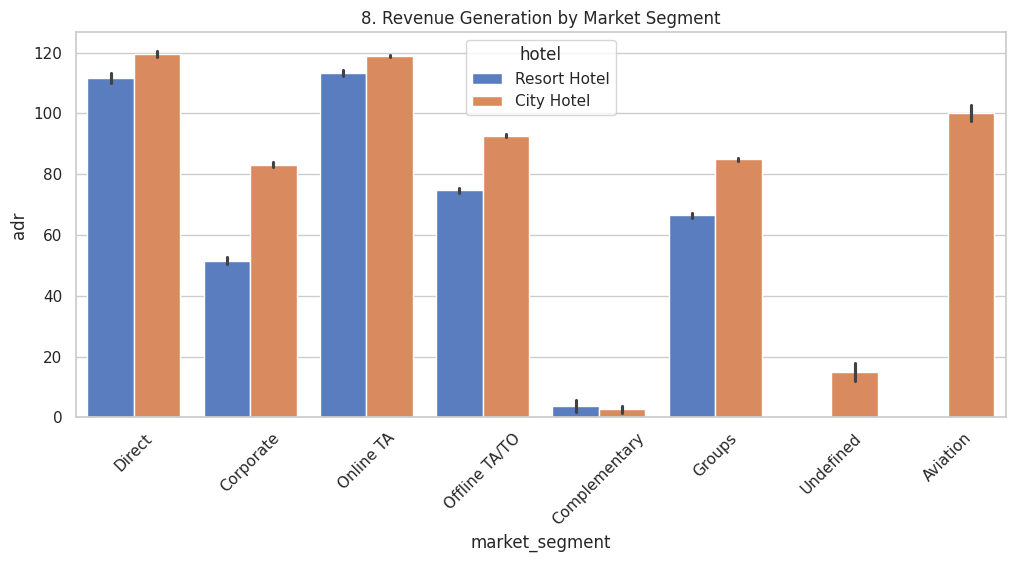

In [103]:

# 8. ADR by Market Segment
plt.figure(figsize=(12, 5))
sns.barplot(x='market_segment', y='adr', hue='hotel', data=df_clean)
plt.title('8. Revenue Generation by Market Segment')
plt.xticks(rotation=45)
plt.show()


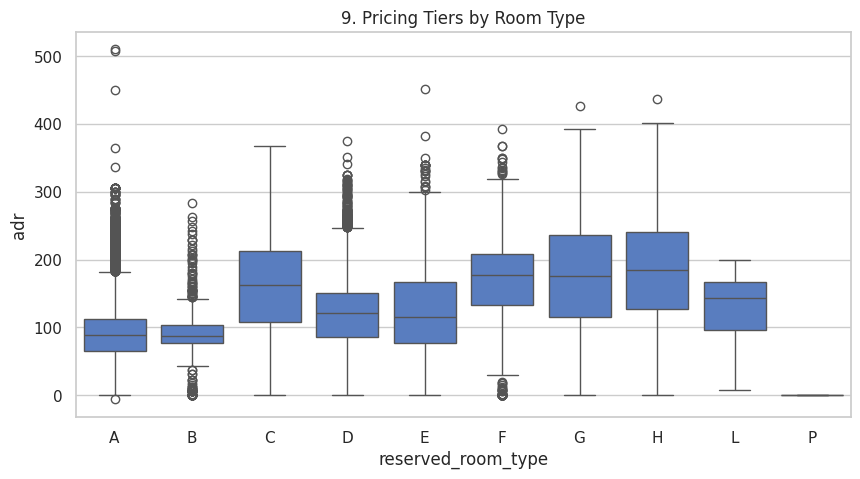

In [104]:

# 9. ADR by Reserved Room Type
plt.figure(figsize=(10, 5))
sns.boxplot(x='reserved_room_type', y='adr', data=df_clean, order=sorted(df_clean['reserved_room_type'].unique()))
plt.title('9. Pricing Tiers by Room Type')
plt.show()


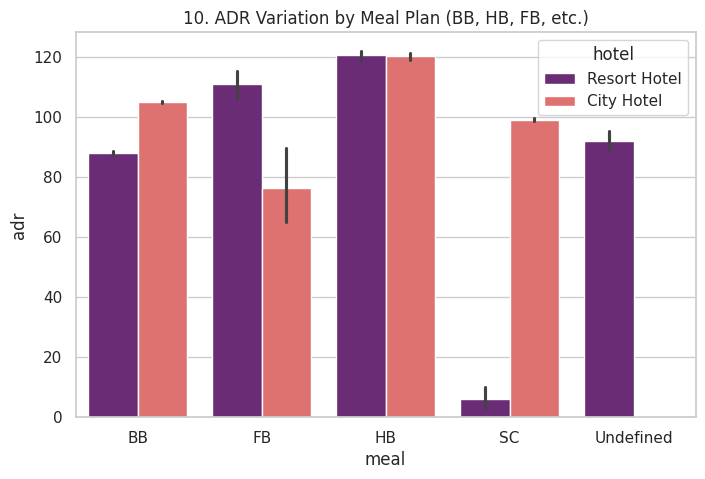

In [106]:

# 10. Impact of Meal Plan on Price
plt.figure(figsize=(8, 5))
sns.barplot(x='meal', y='adr', hue='hotel', data=df_clean, palette='magma')
plt.title('10. ADR Variation by Meal Plan (BB, HB, FB, etc.)')
plt.show()

```
# ==========================================
# SECTION 3: DEMOGRAPHICS & GUESTS (Vis 11-14)
# ==========================================
```

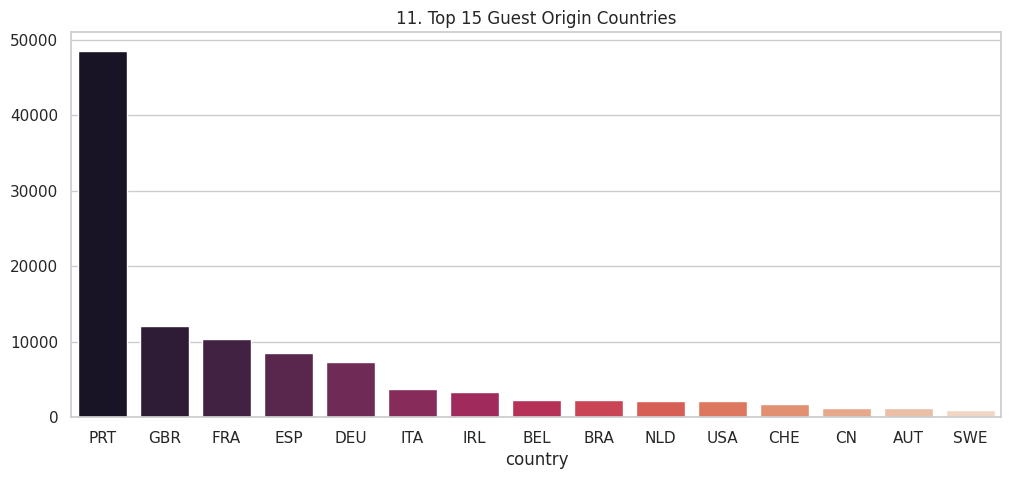

In [107]:
# 11. Top 15 Origin Countries
plt.figure(figsize=(12, 5))
top_countries = df_clean['country'].value_counts().nlargest(15)
sns.barplot(x=top_countries.index, y=top_countries.values, palette='rocket')
plt.title('11. Top 15 Guest Origin Countries')
plt.show()


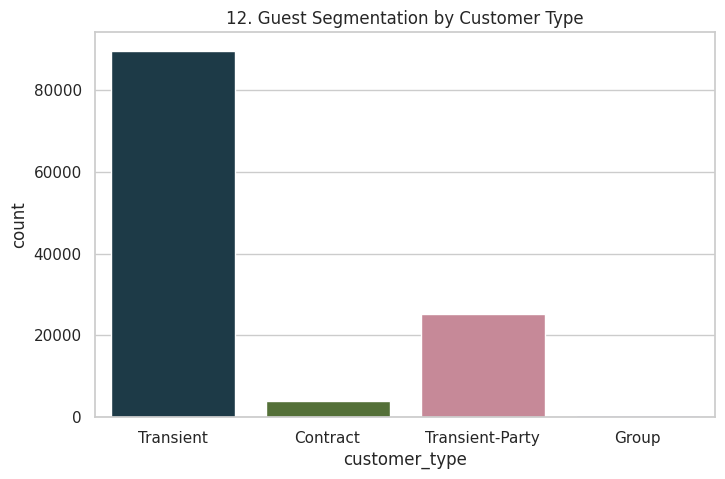

In [108]:

# 12. Customer Type Breakdown
plt.figure(figsize=(8, 5))
sns.countplot(x='customer_type', data=df_clean, palette='cubehelix')
plt.title('12. Guest Segmentation by Customer Type')
plt.show()


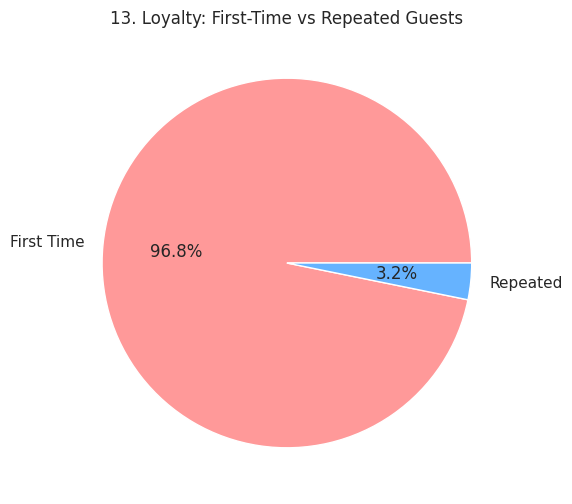

In [109]:

# 13. Repeated Guest Ratio
plt.figure(figsize=(6, 6))
repeated = df_clean['is_repeated_guest'].value_counts()
plt.pie(repeated, labels=['First Time', 'Repeated'], autopct='%1.1f%%', colors=['#ff9999','#66b3ff'])
plt.title('13. Loyalty: First-Time vs Repeated Guests')
plt.show()


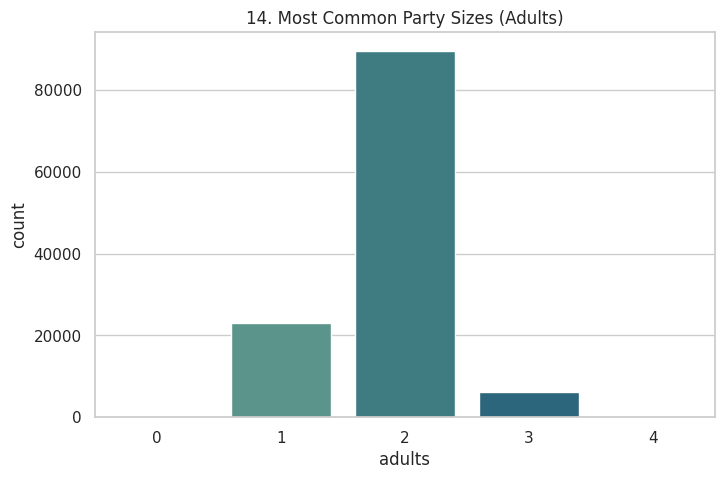

In [110]:

# 14. Party Size (Adults vs Children)
plt.figure(figsize=(8, 5))
sns.countplot(x='adults', data=df_clean[df_clean['adults'] <= 4], palette='crest')
plt.title('14. Most Common Party Sizes (Adults)')
plt.show()


```

# ==========================================
# SECTION 4: CANCELLATIONS & RISK (Vis 15-18)
# ==========================================
```

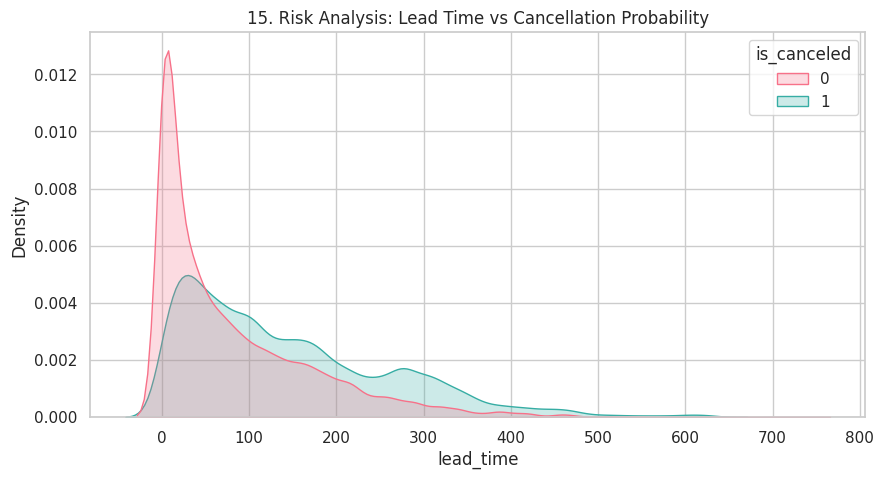

In [111]:
# 15. Lead Time Effect on Cancellations
plt.figure(figsize=(10, 5))
sns.kdeplot(data=df_clean, x='lead_time', hue='is_canceled', fill=True, common_norm=False, palette='husl')
plt.title('15. Risk Analysis: Lead Time vs Cancellation Probability')
plt.show()


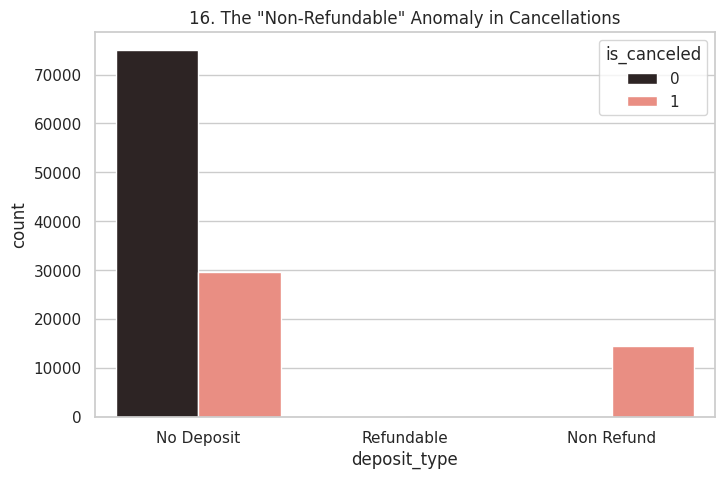

In [112]:

# 16. Deposit Type Risk
plt.figure(figsize=(8, 5))
sns.countplot(x='deposit_type', hue='is_canceled', data=df_clean, palette='dark:salmon')
plt.title('16. The "Non-Refundable" Anomaly in Cancellations')
plt.show()


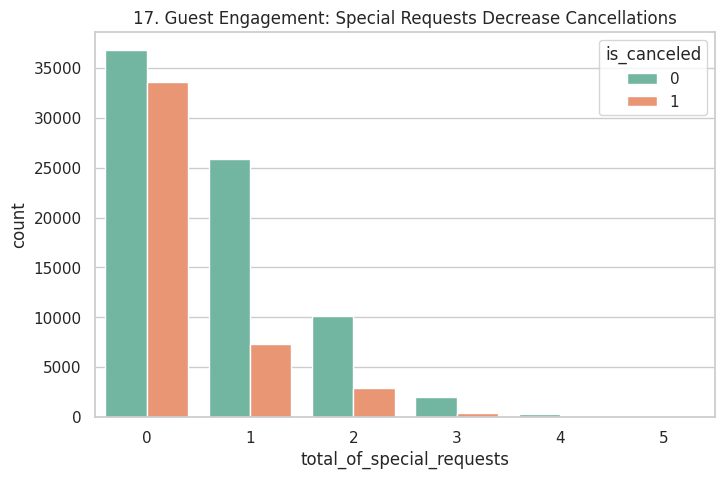

In [113]:

# 17. Special Requests vs Retention
plt.figure(figsize=(8, 5))
sns.countplot(x='total_of_special_requests', hue='is_canceled', data=df_clean, palette='Set2')
plt.title('17. Guest Engagement: Special Requests Decrease Cancellations')
plt.show()


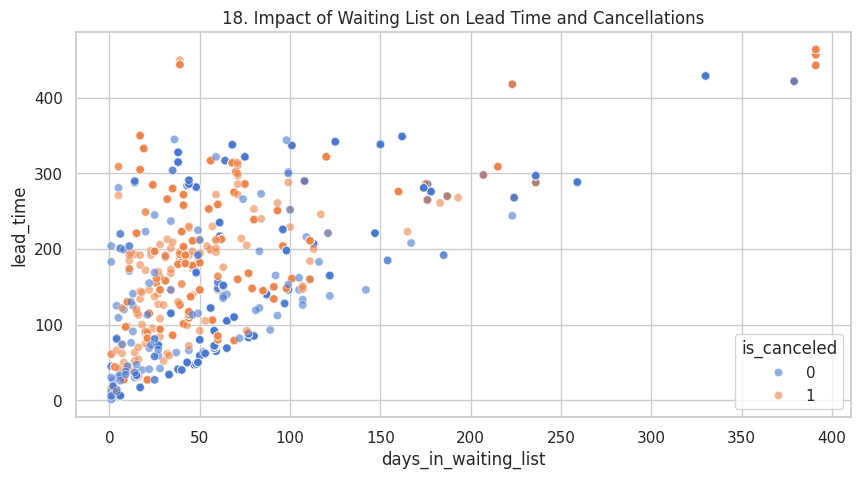

In [114]:
# 18. Waiting List Impact
plt.figure(figsize=(10, 5))
sns.scatterplot(x='days_in_waiting_list', y='lead_time', hue='is_canceled', data=df_clean[df_clean['days_in_waiting_list'] > 0], alpha=0.6)
plt.title('18. Impact of Waiting List on Lead Time and Cancellations')
plt.show()


```
# ==========================================
# SECTION 5: OPERATIONS & STAY BEHAVIOR (Vis 19-20)
# ==========================================
```


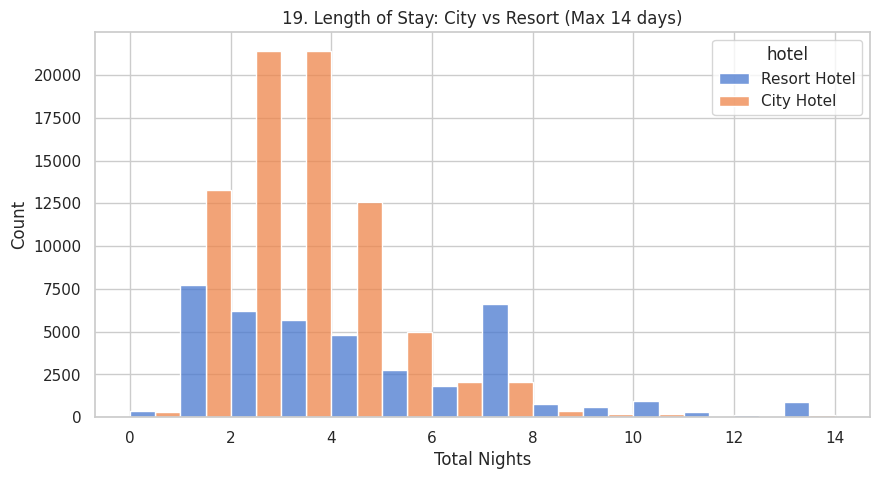

In [115]:
# 19. Total Stay Duration Distribution
plt.figure(figsize=(10, 5))
sns.histplot(data=df_clean[df_clean['total_stay'] <= 14], x='total_stay', hue='hotel', bins=14, multiple="dodge")
plt.title('19. Length of Stay: City vs Resort (Max 14 days)')
plt.xlabel('Total Nights')
plt.show()


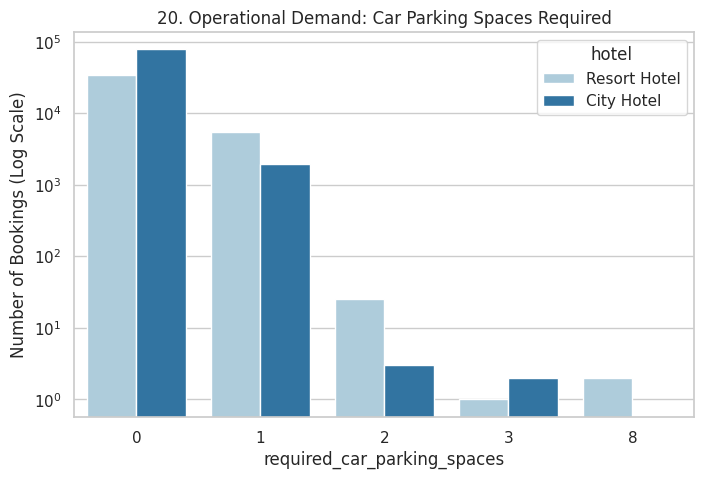

All 20 Business Insight Visualizations Generated Successfully.


In [116]:
# 20. Parking Space Requirements
plt.figure(figsize=(8, 5))
sns.countplot(x='required_car_parking_spaces', hue='hotel', data=df_clean, palette='Paired')
plt.title('20. Operational Demand: Car Parking Spaces Required')
plt.yscale('log') # Log scale used because 0 spaces overwhelmingly dominates
plt.ylabel('Number of Bookings (Log Scale)')
plt.show()

print("All 20 Business Insight Visualizations Generated Successfully.")